## 1. Importing Libraries


In [42]:
# Importing essential libraries for data loading, cleaning, and visualization
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Loading and Combining Monthly Sales Files


In [44]:
# Defining the path for all monthly sales CSV files
path = r"F:\Pandas-Data-Science-Tasks-master\SalesAnalysis\Sales_Data"

# Getting a list of all CSV files in the folder
all_files = glob.glob(path + "/*.csv")

# Combining all monthly files into a single DataFrame
df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

# Saving the combined dataset for future use
df.to_csv("all_sales.csv", index=False)

# Displaying the first few rows to verify the combined data
df.head()


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [3]:
df.shape

(186850, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


## 3. Cleaning the Data


In [45]:
# Checking for missing values in each column
nan_df = df.isnull().sum()
nan_df

# Dropping rows where all columns are NaN
df = df.dropna(how='all')

# Re-checking to confirm that missing rows were removed
nan_df = df.isnull().sum()
nan_df


Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

## 4. Cleaning & Preparing the Data


In [47]:
# Removing repeated header rows
df = df[df['Order Date'] != 'Order Date']

# Converting data types
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Dropping rows with invalid or missing values after conversion
df = df.dropna(subset=['Quantity Ordered', 'Price Each', 'Order Date'])

# Creating the Sales column
df['Sales'] = df['Quantity Ordered'] * df['Price Each']


C:\Users\amira\AppData\Local\Temp\ipykernel_9896\2027401031.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')


## 5. Preparing Data and Adding New Columns


In [48]:
# Adding Month column
df['Month'] = df['Order Date'].dt.month

# Adding Sales column
df['Sales'] = df['Quantity Ordered'] * df['Price Each']

# Extracting City from Purchase Address
df['City'] = df['Purchase Address'].apply(lambda x: x.split(',')[1].strip())

# Reordering columns for better readability
df = df[['Order ID', 'Product', 'Quantity Ordered', 'Price Each',
         'Order Date', 'Month', 'Sales', 'Purchase Address', 'City']]

# Adding Hour column
df['Hour Time'] = df['Order Date'].dt.hour

# Displaying the first few rows to verify new columns
df.head()


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Month,Sales,Purchase Address,City,Hour Time
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,4,23.90,"917 1st St, Dallas, TX 75001",Dallas,8
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,4,99.99,"682 Chestnut St, Boston, MA 02215",Boston,22
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,4,600.00,"669 Spruce St, Los Angeles, CA 90001",Los Angeles,14
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,4,11.99,"669 Spruce St, Los Angeles, CA 90001",Los Angeles,14
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,4,11.99,"333 8th St, Los Angeles, CA 90001",Los Angeles,9


## Q1: What was the best month for sales, and how much was earned?


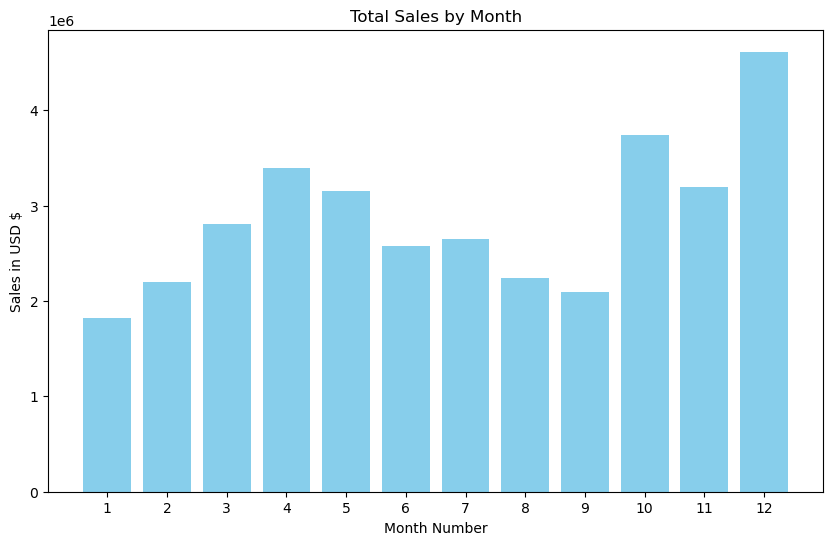

,Sales
Month,
1,1822256.73
2,2202022.42
3,2807100.38
4,3390670.24
5,3152606.75
6,2577802.26
7,2647775.76
8,2244467.88
9,2097560.13


In [49]:
# Calculating total sales per month
result = df.groupby('Month')[['Sales']].sum()

# Plotting monthly sales
plt.figure(figsize=(10,6))
plt.bar(result.index, result['Sales'], color='skyblue')
plt.title('Total Sales by Month')
plt.xlabel('Month Number')
plt.ylabel('Sales in USD $')
plt.xticks(result.index)
plt.show()

result


## Q2: Which city had the highest sales?


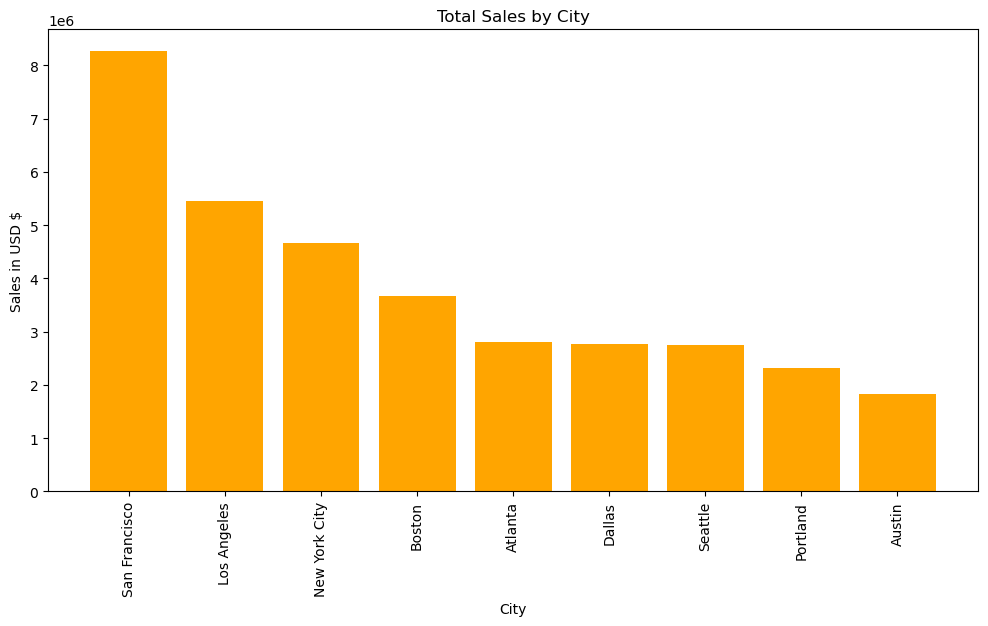

,Sales
City,
San Francisco,8262203.91
Los Angeles,5452570.80
New York City,4664317.43
Boston,3661642.01
Atlanta,2795498.58
Dallas,2767975.40
Seattle,2747755.48
Portland,2320490.61
Austin,1819581.75


In [50]:
# Calculating total sales per city
result = df.groupby('City')[['Sales']].sum().sort_values('Sales', ascending=False)

# Plotting sales by city
plt.figure(figsize=(12,6))
plt.bar(result.index, result['Sales'], color='orange')
plt.title('Total Sales by City')
plt.xlabel('City')
plt.ylabel('Sales in USD $')
plt.xticks(result.index, rotation='vertical', fontsize=10)
plt.show()

result


## Q3: What time should we display advertisements to maximize customer purchases?


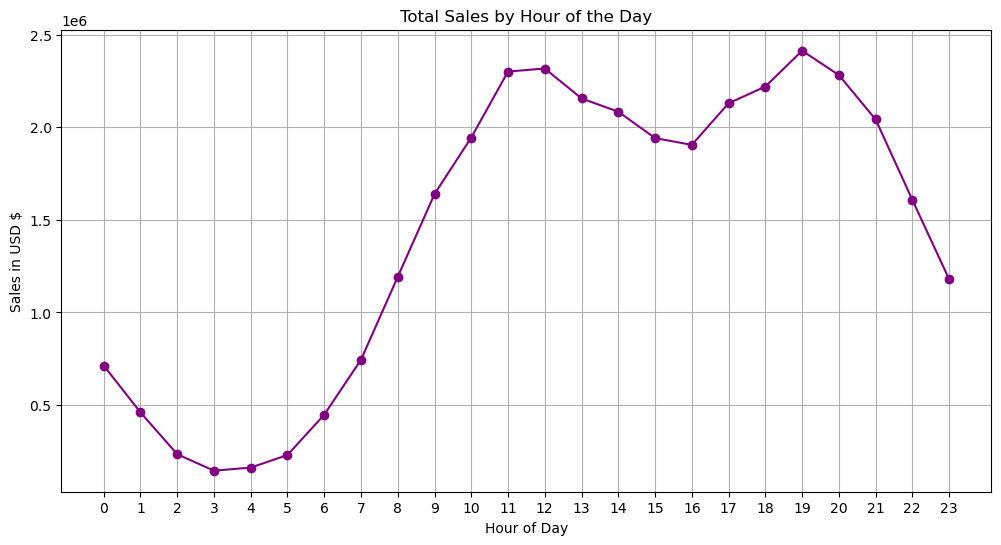

,Sales
Hour Time,
0,713721.27
1,460866.88
2,234851.44
3,145757.89
4,162661.01
5,230679.82
6,448113.00
7,744854.12
8,1192348.97


In [51]:
# Calculating total sales per hour
result = df.groupby('Hour Time')[['Sales']].sum()

# Plotting sales by hour
plt.figure(figsize=(12,6))
plt.plot(result.index, result['Sales'], marker='o', color='purple')
plt.title('Total Sales by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Sales in USD $')
plt.xticks(result.index)
plt.grid(True)
plt.show()

result


### 📝 Insight
Customer purchases peak around **11 AM** and again around **7 PM**, making these the best times to display advertisements for maximum impact.


## Q4: Which products are most often sold together?


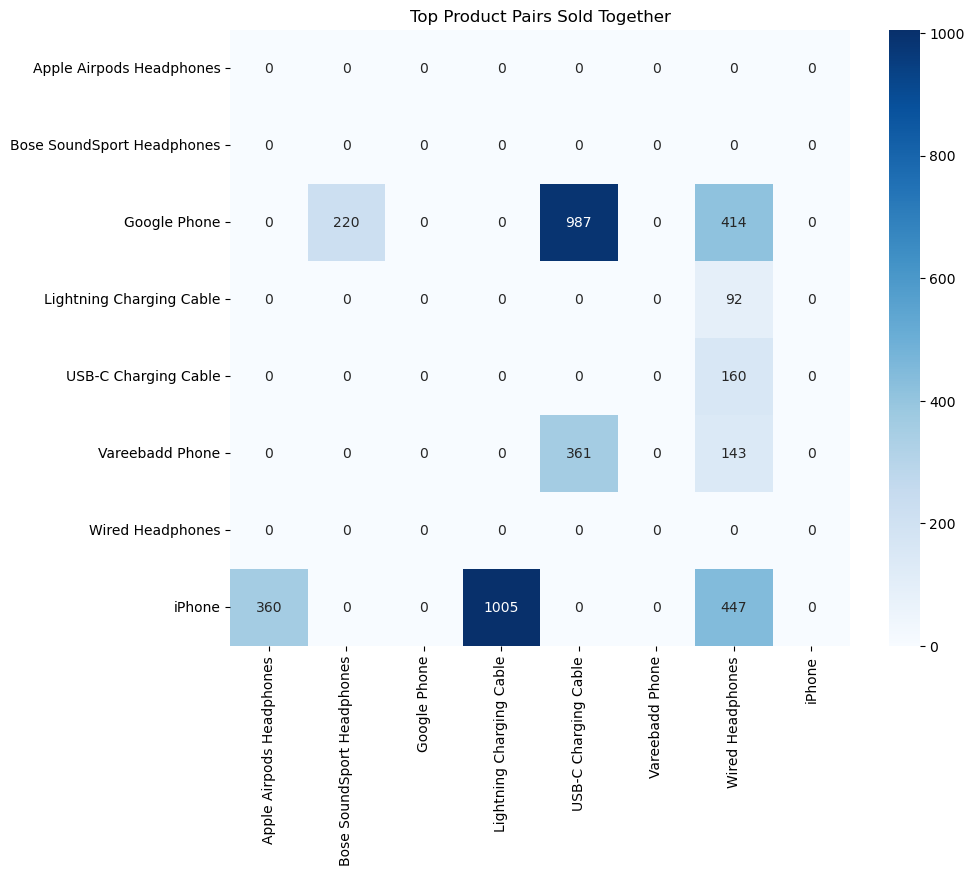

,Pair,Count
8,"(iPhone, Lightning Charging Cable)",1005
1,"(Google Phone, USB-C Charging Cable)",987
13,"(iPhone, Wired Headphones)",447
0,"(Google Phone, Wired Headphones)",414
22,"(Vareebadd Phone, USB-C Charging Cable)",361
16,"(iPhone, Apple Airpods Headphones)",360
9,"(Google Phone, Bose SoundSport Headphones)",220
37,"(USB-C Charging Cable, Wired Headphones)",160
46,"(Vareebadd Phone, Wired Headphones)",143
81,"(Lightning Charging Cable, Wired Headphones)",92


In [52]:
from itertools import combinations
from collections import Counter

# Filtering orders that contain multiple products
df_multi = df[df['Order ID'].duplicated(keep=False)].copy()

# Grouping products within the same Order ID
df_multi['Grouped'] = df_multi.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))

# Keeping only one row per Order ID
df_grouped = df_multi[['Order ID', 'Grouped']].drop_duplicates()

# Counting product pairs
count = Counter()
for row in df_grouped['Grouped']:
    products = row.split(',')
    count.update(Counter(combinations(products, 2)))

# Converting pair counts into a DataFrame
pairs_df = pd.DataFrame(count.items(), columns=['Pair', 'Count'])

# Selecting top 10 pairs
top_pairs = pairs_df.sort_values('Count', ascending=False).head(10)

# Preparing matrix for heatmap
products_in_pairs = sorted(list(set([p for pair in top_pairs['Pair'] for p in pair])))
matrix = pd.DataFrame(0, index=products_in_pairs, columns=products_in_pairs)

for (p1, p2), c in top_pairs.set_index('Pair')['Count'].items():
    matrix.loc[p1, p2] = c

# Plotting heatmap
plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True, fmt='g', cmap='Blues')
plt.title('Top Product Pairs Sold Together')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

top_pairs


#### 📄 Why do these products appear together?

The heatmap shows that certain products are frequently purchased **in the same order**, especially when one of them is a **main device** and the other is an **essential accessory**. These combinations naturally appear more often because:

- Customers buy the **device + accessory** together in one purchase.  
- Accessories like **Lightning Cable** and **USB‑C Cable** are needed for many devices.  
- These items are often added **as low‑cost add‑ons**.  
- Their essential nature makes them appear repeatedly across orders.  
- The pattern reflects clear **bundling behavior** from customers.

Overall, the strong co‑purchase patterns highlight natural opportunities for **bundling devices with their accessories** to increase sales.


## Q5 : what product sold the most ? why do you think it sold the most ?

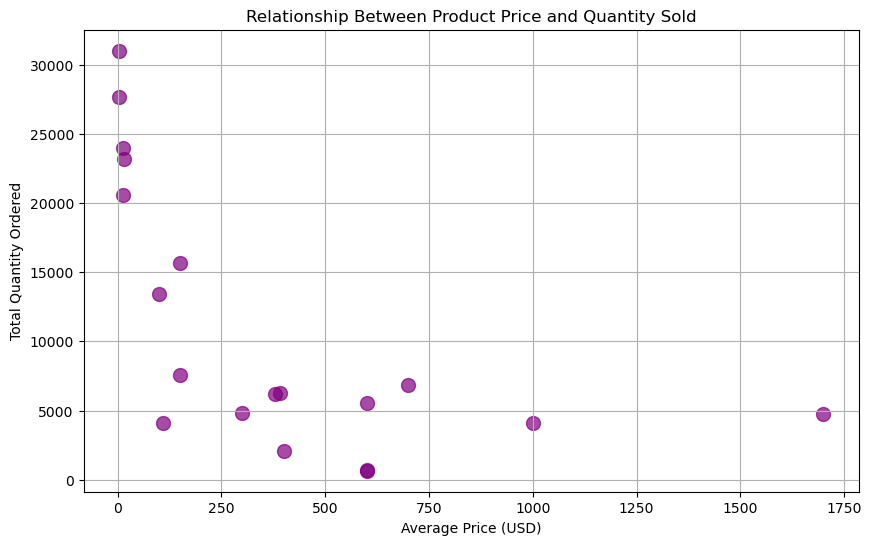

In [54]:
# Preparing product statistics
product_stats = df.groupby('Product').agg({
    'Quantity Ordered': 'sum',
    'Price Each': 'mean'
}).reset_index()

# Scatter plot: price vs quantity sold
plt.figure(figsize=(10,6))
plt.scatter(
    product_stats['Price Each'],
    product_stats['Quantity Ordered'],
    color='purple',
    s=100,
    alpha=0.7
)

plt.xlabel('Average Price (USD)')
plt.ylabel('Total Quantity Ordered')
plt.title('Relationship Between Product Price and Quantity Sold')
plt.grid(True)
plt.show()


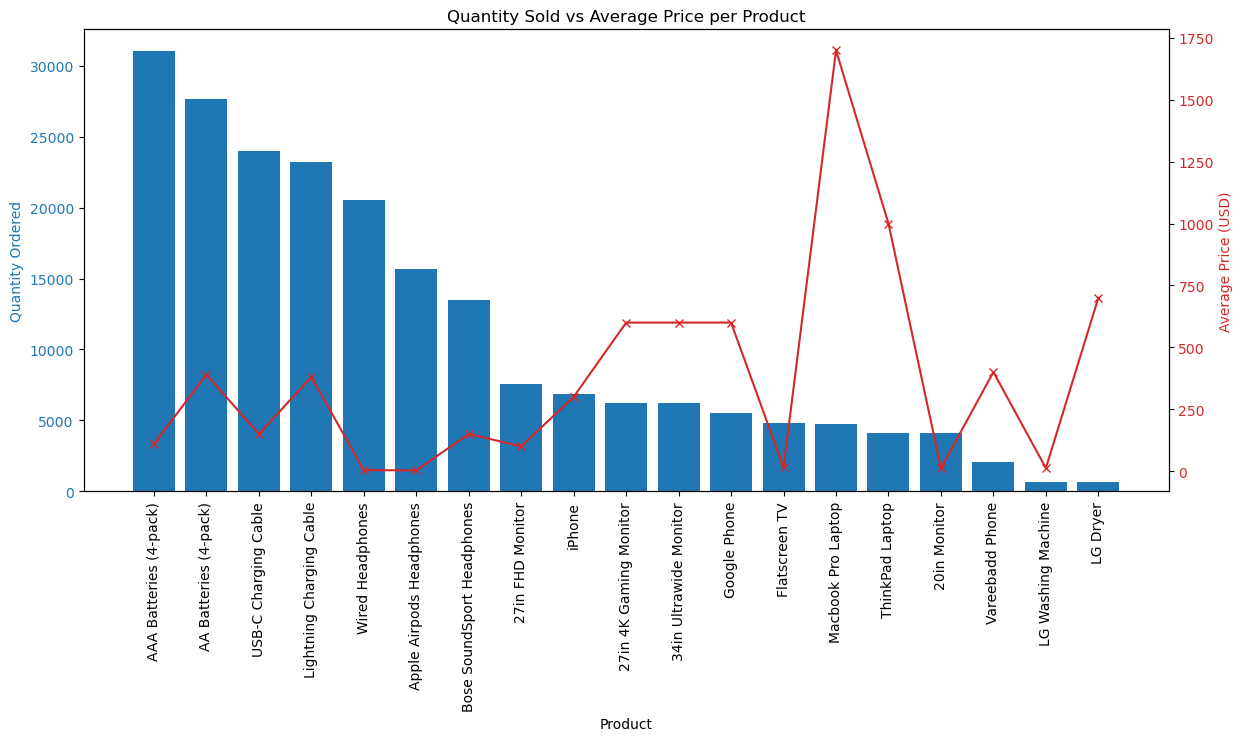

Product
AAA Batteries (4-pack)        31017
AA Batteries (4-pack)         27635
USB-C Charging Cable          23975
Lightning Charging Cable      23217
Wired Headphones              20557
Apple Airpods Headphones      15661
Bose SoundSport Headphones    13457
27in FHD Monitor               7550
iPhone                         6849
27in 4K Gaming Monitor         6244
Name: Quantity Ordered, dtype: int64

In [53]:
# Total quantity sold per product
product_group = df.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)

# Average price per product
prices = df.groupby('Product')['Price Each'].mean()

products = product_group.index
quantity = product_group.values

# Plotting quantity vs price
fig, ax1 = plt.subplots(figsize=(14,6))

# Bar chart for quantity sold
ax1.bar(products, quantity, color='tab:blue')
ax1.set_xlabel('Product')
ax1.set_ylabel('Quantity Ordered', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
plt.xticks(rotation=90)

# Line chart for average price
ax2 = ax1.twinx()
ax2.plot(products, prices, color='tab:red', marker='x')
ax2.set_ylabel('Average Price (USD)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Quantity Sold vs Average Price per Product')
plt.show()

product_group.head(10)



#### 📄 Why did this product sell the most?

The product that sold the most was a **low‑cost essential item** (such as batteries or charging cables).  
These products typically have **very high demand** because:

- Customers buy them **frequently**.  
- They are used with **many different devices**.  
- They are often purchased **as add-ons** alongside other products.  
- Their **low price** encourages customers to buy multiple units.  
- They are considered **everyday essentials**, so the sales volume is naturally high.

Overall, the combination of **low price**, **high utility**, and **frequent replacement** makes these items the top-selling products.


## 📌 Final Summary / الملخص النهائي

After analyzing 12 months of sales data, several key insights were discovered:

بعد تحليل بيانات المبيعات لمدة 12 شهر، ظهرت مجموعة من النتائج المهمة:

---

### 🔹 1. Best Month for Sales / أفضل شهر للمبيعات
- **December** had the highest revenue due to holiday shopping.  
- شهر **ديسمبر** كان الأعلى في المبيعات بسبب موسم الأعياد.

---

### 🔹 2. Best Performing City / أفضل مدينة في المبيعات
- **San Francisco** generated the highest total sales.  
- مدينة **سان فرانسيسكو** حققت أعلى مبيعات إجمالية.

---

### 🔹 3. Best Time for Advertising / أفضل وقت للإعلانات
- Sales peak around **11 AM** and **7 PM**.  
- المبيعات بتوصل لأعلى مستوى حوالي **11 صباحًا** و **7 مساءً**.

---

### 🔹 4. Products Sold Together / المنتجات الأكثر بيعًا معًا
- iPhone + Lightning Cable  
- Google Phone + USB‑C Cable  
- iPhone + Wired Headphones  
- المنتجات دي بتتباع مع بعض بشكل متكرر جدًا، وده بيوضح فرص ممتازة للـ Cross‑Selling.

---

### 🔹 5. Best-Selling Products & Pricing Effect  
### المنتجات الأكثر مبيعًا وتأثير السعر
- Low‑priced items like batteries and cables sold the most.  
- المنتجات الرخيصة زي البطاريات والكيابل كانت الأعلى مبيعًا.
- Clear negative relationship: **lower price → higher quantity sold**  
- في علاقة عكسية واضحة: **كل ما السعر يقل → الكمية تزيد**.

---

### 🎯 Final Conclusion / الخلاصة
This analysis reveals strong seasonal trends, city‑level differences, optimal ad timing, and powerful product bundling opportunities.

التحليل ده وضّح اتجاهات موسمية قوية، اختلافات بين المدن، أفضل أوقات للإعلانات، وفرص ممتازة لبيع المنتجات مع بعض.
